# Importar Bibliotecas e Carregar Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Divisão de Variáveis e Treinamento do Modelo (Proporção 70/30)

In [3]:
X = df.drop(["id", "date", "price"], axis=1)
y = df["price"]
features_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

# Cálculo das Métricas de Avaliação

In [4]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (Erro Médio Absoluto): ${mae:,.2f}")
print(f"MSE (Erro Quadrático Médio): {mse:,.2f}")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")

MAE (Erro Médio Absoluto): $127,486.80
MSE (Erro Quadrático Médio): 43,387,526,779.35
R² (Coeficiente de Determinação): 0.6995


# Visualização da Reta de Regressão (Quartos vs Preço Ajustado)


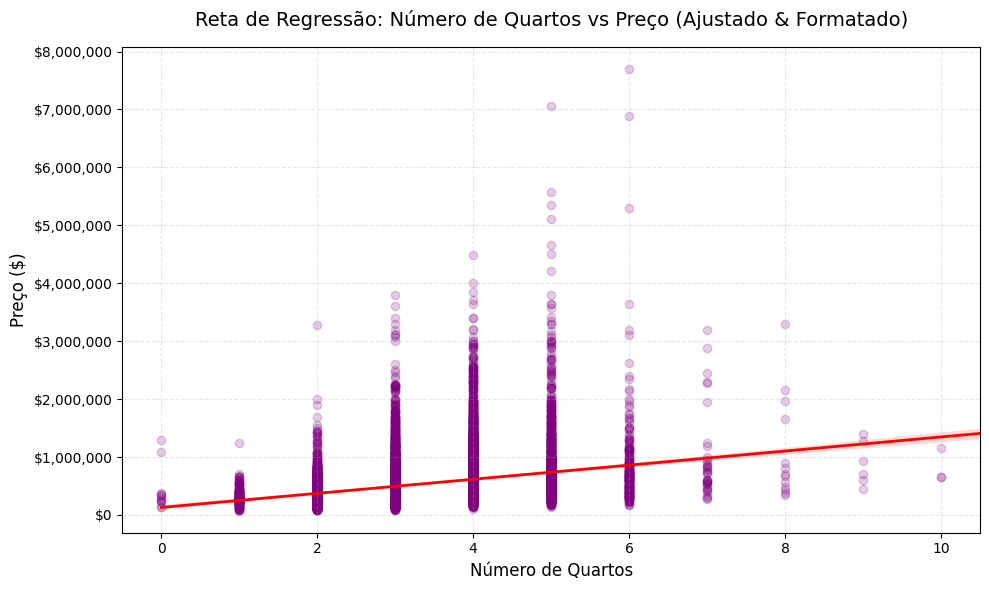

In [5]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df, x='bedrooms', y='price', scatter_kws={'alpha': 0.2, 'color': 'purple'}, line_kws={'color': 'red', 'linewidth': 2})
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))
plt.xlim(-0.5, 10.5)
plt.title('Reta de Regressão: Número de Quartos vs Preço', fontsize=14, pad=15)
plt.xlabel('Número de Quartos', fontsize=12)
plt.ylabel('Preço ($)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Extração e Análise dos Coeficientes

In [6]:
df_coef = pd.DataFrame({'Variável': features_names, 'Coeficiente': modelo.coef_})
df_coef = df_coef.sort_values(by='Coeficiente', ascending=False)
df_coef.reset_index(drop=True, inplace=True)
print(df_coef)

         Variável    Coeficiente
0             lat  595216.324057
1      waterfront  543877.176919
2           grade   94908.179367
3            view   55083.061566
4       bathrooms   40312.969982
5       condition   23146.067309
6          floors    5271.542181
7     sqft_living     112.001375
8      sqft_above      72.219067
9   sqft_basement      39.782308
10   yr_renovated      21.920973
11  sqft_living15      16.207749
12       sqft_lot       0.099184
13     sqft_lot15      -0.330430
14        zipcode    -556.358731
15       yr_built   -2594.418469
16       bedrooms  -34308.147744
17           long -196904.658005


# Gráfico do impacto dos coeficientes

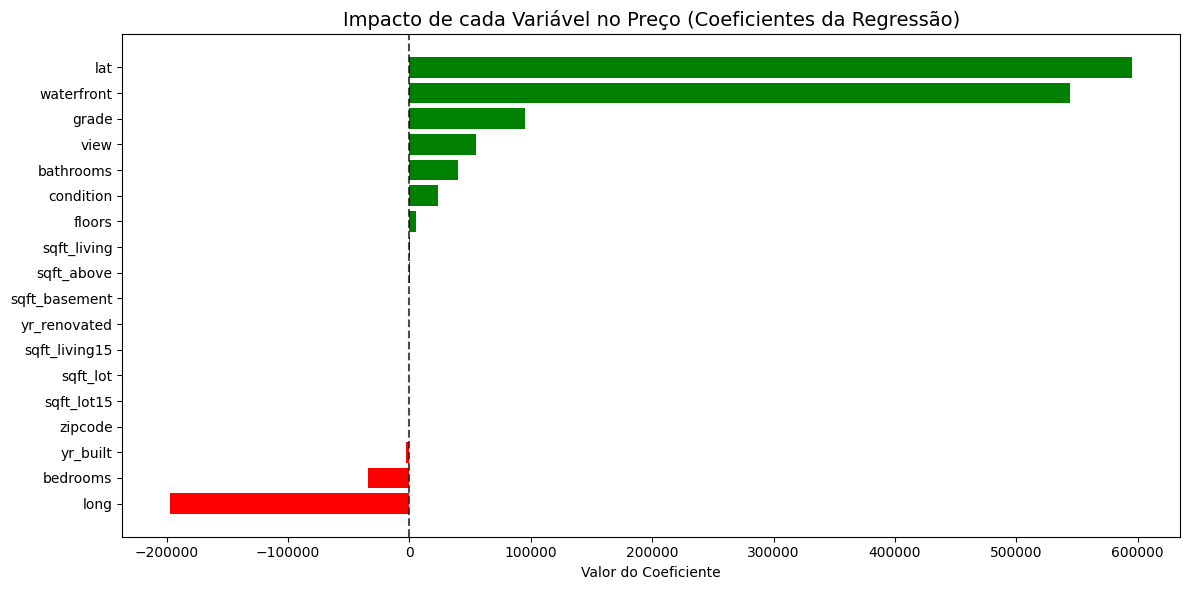

In [7]:
plt.figure(figsize=(12, 6))
df_coef_sorted = df_coef.sort_values(by='Coeficiente', ascending=True)
colors = ['red' if x < 0 else 'green' for x in df_coef_sorted['Coeficiente']]

plt.barh(df_coef_sorted['Variável'], df_coef_sorted['Coeficiente'], color=colors)
plt.axvline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Impacto de cada Variável no Preço (Coeficientes da Regressão)', fontsize=14)
plt.xlabel('Valor do Coeficiente')
plt.tight_layout()
plt.show()

# Gráfico da Performance do Modelo

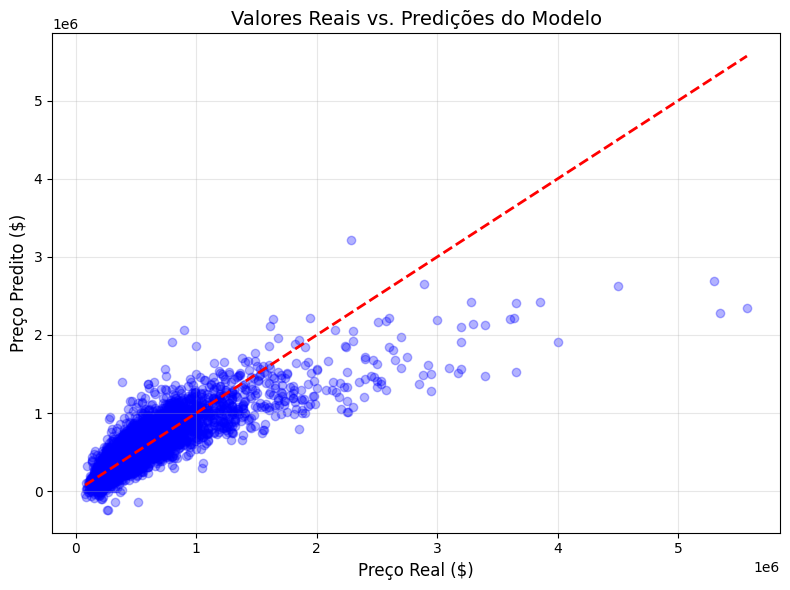

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Valores Reais vs. Predições do Modelo', fontsize=14)
plt.xlabel('Preço Real ($)', fontsize=12)
plt.ylabel('Preço Predito ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Respostas

## 3. Respostas do Exercício

### Quais foram os valores de MAE, MSE e R2?
* MAE: 127,474.10
* MSE: 45,414,514,642.14
* R²: 0.6990 (69.90%)

### O que o R2 indica sobre a qualidade do modelo?
O R² de 0.6990 indica que aproximadamente 69.90% da variação nos preços dos imóveis é explicada pelas variáveis independentes do modelo. Para dados reais de mercado imobiliário, esse resultado demonstra que o modelo possui uma boa capacidade preditiva e captura a maior parte da tendência dos preços.

### Quais variáveis tiveram coeficientes positivos? E negativos?
* Coeficientes Positivos: lat, waterfront, grade, view, bathrooms, condition, floors
* Coeficientes Negativos: long, bedrooms e yr_built.

### Qual variável parece influenciar mais o preço?
A variável que mais influencia o preço de forma absoluta é a latitude (lat), seguida de perto pela presença de vista para a água (waterfront). Ambas apresentam os maiores coeficientes no modelo, o que significa que a localização geográfica ao norte e o diferencial estético/local do imóvel causam os maiores impactos diretos no valor final do metro quadrado na região.